In [97]:
import pvlib
from pvlib.location import Location
from pvlib.pvsystem import PVSystem, Array, FixedMount
from pvlib.modelchain import ModelChain
import pandas as pd
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv

print('Libraries imported!')

Libraries imported!


In [98]:
load_dotenv()

API_KEY = os.getenv('NLR_API_KEY')
EMAIL = os.getenv('RESEARCH_EMAIL')

# latitude, longitude, name, altitude, timezone
locations = [
    Location(
        latitude=37.2753,
        longitude=-107.8801,
        altitude=1990.6488,
        name='Durango'
    )
]

print('Locations')
print('-'*50)
for location in locations:
    print('Name:', location.name)
    print('Latitude', location.latitude)
    print('Longitude', location.longitude)
    print()

Locations
--------------------------------------------------
Name: Durango
Latitude 37.2753
Longitude -107.8801



In [99]:
def normalize_weather_data(weather_df: pd.DataFrame) -> pd.DataFrame:
    """Return chronologically indexed weather data in pvlib-compatible units."""
    weather_df = weather_df.copy()
    if not isinstance(weather_df.index, pd.DatetimeIndex):
        if 'Datetime' not in weather_df.columns:
            raise ValueError('Weather data must contain a Datetime column.')
        weather_df['Datetime'] = pd.to_datetime(weather_df['Datetime'], errors='raise')
        weather_df = weather_df.set_index('Datetime')
    weather_df.index = pd.DatetimeIndex(weather_df.index, name='Datetime')
    weather_df = weather_df[~weather_df.index.duplicated(keep='first')].sort_index()

    model_columns = ['ghi', 'dni', 'dhi', 'temp_air', 'wind_speed', 'pressure']
    missing_columns = set(model_columns).difference(weather_df.columns)
    if missing_columns:
        raise ValueError(f'Missing required weather columns: {sorted(missing_columns)}')
    weather_df[model_columns] = weather_df[model_columns].apply(pd.to_numeric, errors='raise')

    # NSRDB pressure is stored near 790 mbar; pvlib expects pressure in pascals.
    if weather_df['pressure'].median() < 2_000:
        weather_df['pressure'] = weather_df['pressure'] * 100
    return weather_df

def generate_weather_data(
    location: Location,
    api_key: str | None = API_KEY,
    email: str | None = EMAIL,
    year: int = 2023,
    time_step: int = 5,
    is_exported_to_csv: bool = True,
) -> tuple[pd.DataFrame, dict[str, str]]:
    weather_df, metadata = pvlib.iotools.get_nsrdb_psm4_conus(
        latitude=location.latitude,
        longitude=location.longitude,
        api_key=api_key,
        email=email,
        year=year,
        time_step=time_step,
        parameters=[
            'ghi',
            'dni',
            'dhi',
            'air_temperature',
            'wind_speed',
            'surface_pressure',
        ],
        leap_day=True,
        utc=False,
        map_variables=True,
    )
    
    weather_df = normalize_weather_data(weather_df)

    if is_exported_to_csv:
        weather_df.to_csv(f'../data/{location.name}_weather_data_{year}_{time_step}_min_res.csv')

    return weather_df, metadata

def load_weather_data(location: Location, year: int, time_step: int) -> pd.DataFrame:
    path = f'../data/{location.name}_weather_data_{year}_{time_step}_min_res.csv'
    if os.path.isfile(path):
        print('Loading existing csv...')
        return normalize_weather_data(pd.read_csv(path))
    df, metadata = generate_weather_data(location)
    print('Weather data not found. Generating new file with location...')
    print(metadata)
    return df

In [100]:
# get weather data
weather_df = load_weather_data(locations[0], 2023, 5)
weather_df.head()

Loading existing csv...


,Year,Month,Day,Hour,Minute,ghi,dni,dhi,temp_air,wind_speed,pressure
Datetime,,,,,,,,,,,
2023-01-01 00:00:00-07:00,2023,1,1,0,0,0.0,0.0,0.0,1.9,1.8,79000.0
2023-01-01 00:05:00-07:00,2023,1,1,0,5,0.0,0.0,0.0,1.9,1.8,79000.0
2023-01-01 00:10:00-07:00,2023,1,1,0,10,0.0,0.0,0.0,1.9,1.8,79000.0
2023-01-01 00:15:00-07:00,2023,1,1,0,15,0.0,0.0,0.0,1.9,1.8,79000.0
2023-01-01 00:20:00-07:00,2023,1,1,0,20,0.0,0.0,0.0,1.9,1.8,79000.0


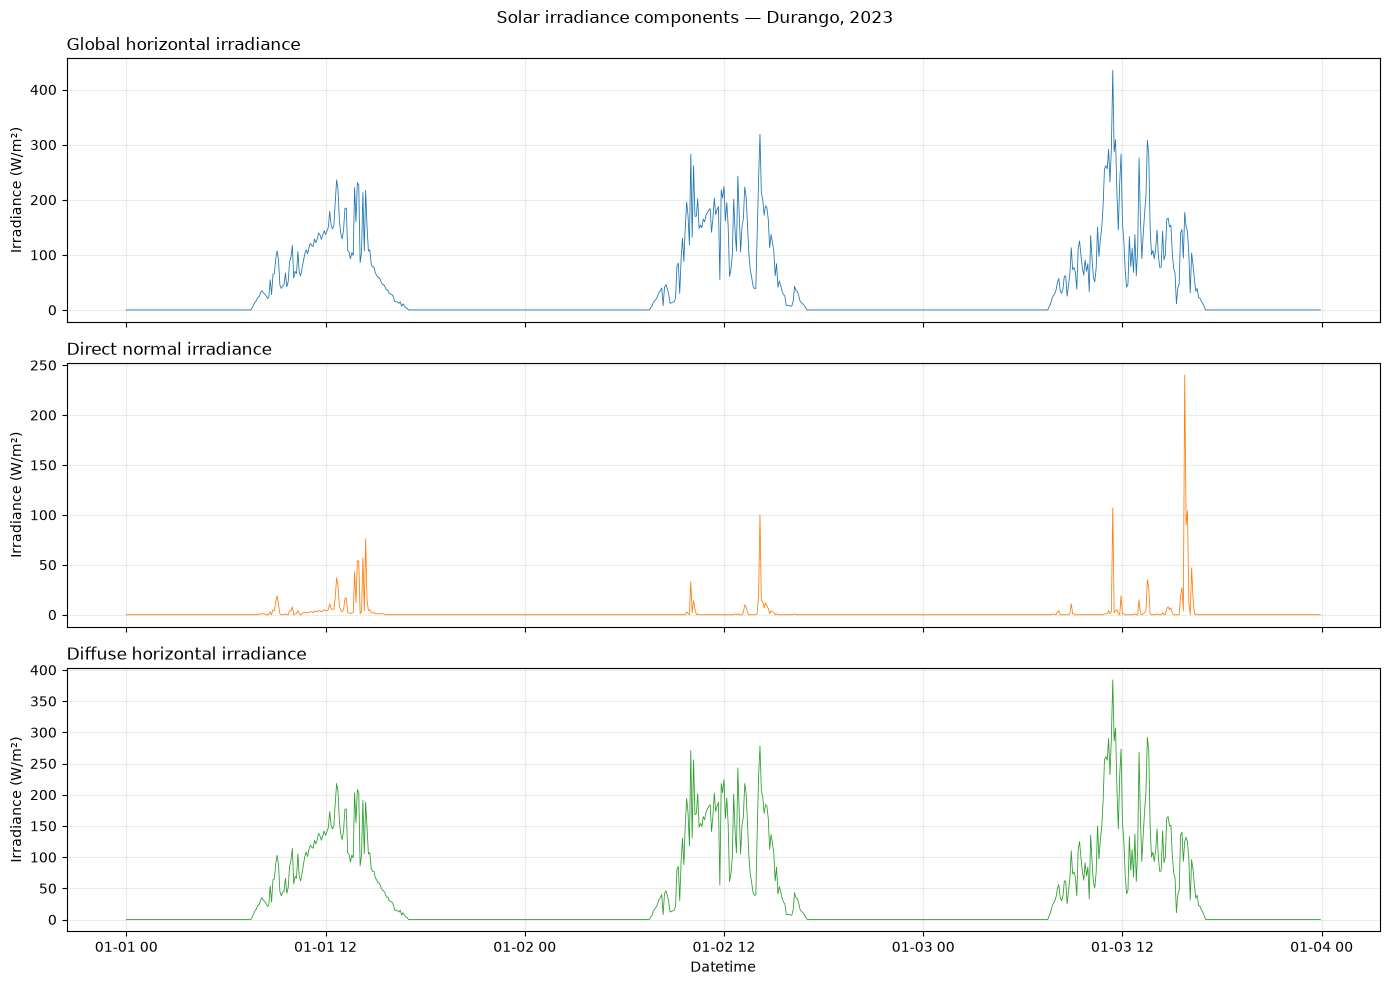

In [101]:
# Shared zero-based index range for every plot; the end index is exclusive.
# At five-minute resolution, 864 samples cover the first three days.
plot_start_index = 0
plot_end_index = 3 * 24 * 60 // 5
if not 0 <= plot_start_index < plot_end_index <= len(weather_df):
    raise ValueError('Plot index range is outside the available weather data.')
weather_plot = weather_df.iloc[plot_start_index:plot_end_index]

irradiance_components = {
    'ghi': ('Global horizontal irradiance', 'tab:blue'),
    'dni': ('Direct normal irradiance', 'tab:orange'),
    'dhi': ('Diffuse horizontal irradiance', 'tab:green'),
}
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for axis, (column, (title, color)) in zip(axes, irradiance_components.items()):
    axis.plot(weather_plot.index, weather_plot[column], color=color, linewidth=0.6)
    axis.set_title(title, loc='left')
    axis.set_ylabel('Irradiance (W/m²)')
    axis.grid(alpha=0.25)
axes[-1].set_xlabel('Datetime')
fig.suptitle(f'Solar irradiance components — {locations[0].name}, 2023')
fig.tight_layout()
plt.show()

In [105]:
# get module and inverter specs from SAM
sandia_modules = pvlib.pvsystem.retrieve_sam('SandiaMod')
sapm_inverters = pvlib.pvsystem.retrieve_sam('cecinverter')

module_name = 'Canadian_Solar_CS5P_220M___2009_'
inverter_name = 'Yaskawa_Solectria_Solar__PVI_85kW_480__480V_'

module = sandia_modules[module_name]
inverter = sapm_inverters[inverter_name]
temperature_model_parameters = pvlib.temperature.TEMPERATURE_MODEL_PARAMETERS['sapm']['open_rack_glass_glass']

module_params = sandia_modules[module_name]
inverter_params = sapm_inverters[inverter_name]

print('Module parameters')
print('-'*100)
print(module_params)

print('Inverter parameters')
print('-'*100)
print(inverter_params)

Module parameters
----------------------------------------------------------------------------------------------------
Vintage                                                          2009
Area                                                            1.701
Material                                                         c-Si
Cells_in_Series                                                    96
Parallel_Strings                                                    1
Isco                                                          5.09115
Voco                                                          59.2608
Impo                                                          4.54629
Vmpo                                                          48.3156
Aisc                                                         0.000397
Aimp                                                         0.000181
C0                                                            1.01284
C1                                       

In [103]:
# ModelChain aligns all weather series on this timezone-aware DatetimeIndex.
assert isinstance(weather_df.index, pd.DatetimeIndex)
assert weather_df.index.is_monotonic_increasing and weather_df.index.is_unique
assert not weather_df[['ghi', 'dni', 'dhi', 'temp_air', 'wind_speed']].isna().any().any()
location = locations[0]
mount = FixedMount(
    surface_tilt=location.latitude,
    surface_azimuth=180,
)
array = Array(
    mount=mount,
    module_parameters=module,
    temperature_model_parameters=temperature_model_parameters,
)
system = PVSystem(
    arrays=[array],
    inverter_parameters=inverter,
)
mc = ModelChain(
    system=system,
    location=location,
)
mc.run_model(weather_df)

ModelChain: 
  name: None
  clearsky_model: ineichen
  transposition_model: haydavies
  solar_position_method: nrel_numpy
  airmass_model: kastenyoung1989
  dc_model: sapm
  ac_model: sandia_inverter
  aoi_model: sapm_aoi_loss
  spectral_model: no_spectral_loss
  temperature_model: sapm_temp
  losses_model: no_extra_losses

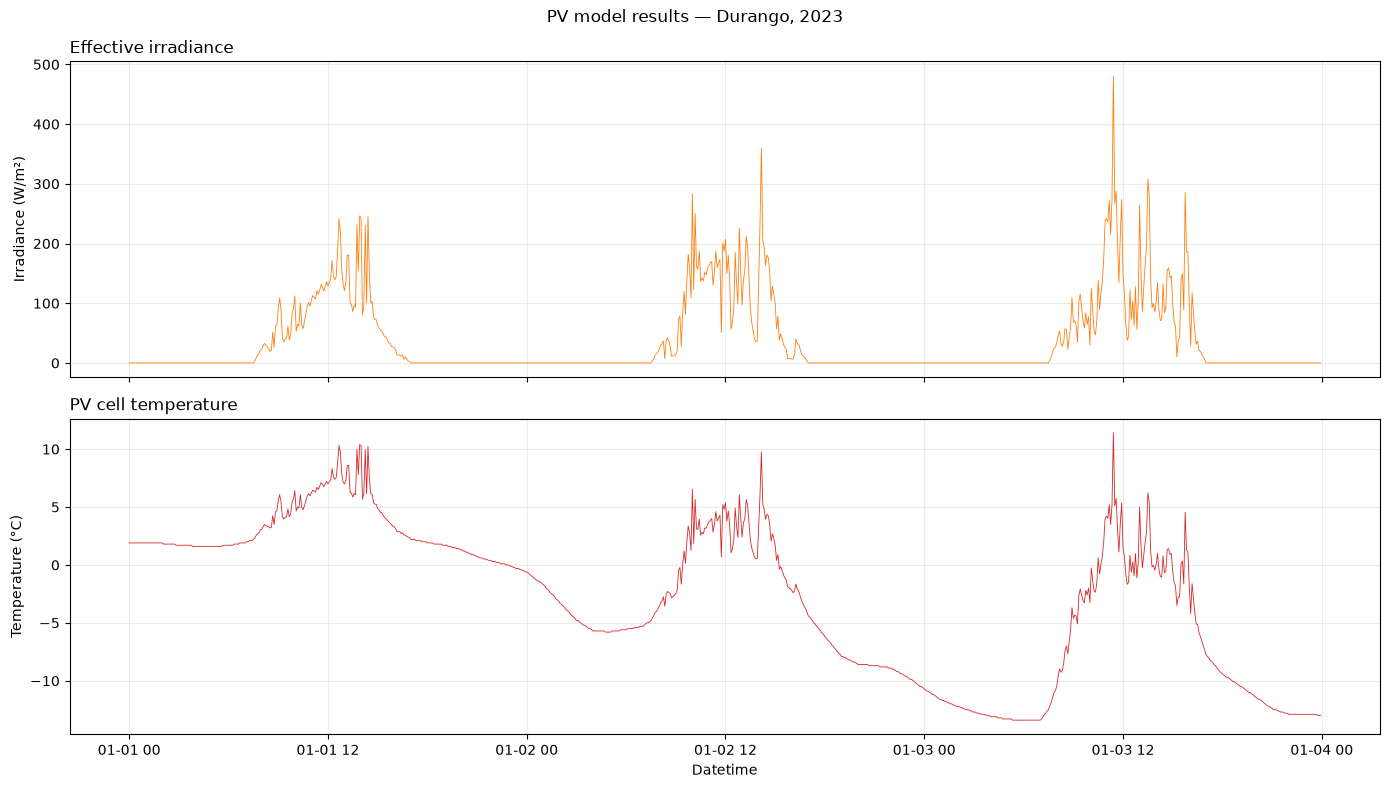

In [104]:
irradiances = mc.results.effective_irradiance
temperatures = mc.results.cell_temperature

# ModelChain returns one Series per array; this system contains one array.
if isinstance(irradiances, (tuple, list)):
    irradiances = irradiances[0]
if isinstance(temperatures, (tuple, list)):
    temperatures = temperatures[0]

irradiance_plot = irradiances.iloc[plot_start_index:plot_end_index]
temperature_plot = temperatures.iloc[plot_start_index:plot_end_index]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(
    irradiance_plot.index, irradiance_plot, color='tab:orange', linewidth=0.6
)
axes[0].set_title('Effective irradiance', loc='left')
axes[0].set_ylabel('Irradiance (W/m²)')
axes[0].grid(alpha=0.25)

axes[1].plot(
    temperature_plot.index, temperature_plot, color='tab:red', linewidth=0.6
)
axes[1].set_title('PV cell temperature', loc='left')
axes[1].set_ylabel('Temperature (°C)')
axes[1].set_xlabel('Datetime')
axes[1].grid(alpha=0.25)

fig.suptitle(f'PV model results — {location.name}, 2023')
fig.tight_layout()
plt.show()